# Credibility Assessment: Hit Rate Analysis
**Author:** Zihan Liu  
**Purpose:** Calculate hit rate of YouTube videos from verified organizations

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 80)

## 1. Create Verified Organizations Database

In [2]:
MASTER_FILE = 'data/Transplants_Team_Master_File.xlsx'
VERIFIED_DB = 'verified_organizations.db'
VIDEO_DB = '../youtube_data.db'

master_df = pd.read_excel(MASTER_FILE)
print(f"Loaded {len(master_df)} organizations from master file")

db_df = master_df[['Organization', 'YouTube_Channel']].copy()
db_df.columns = ['organization', 'youtube_channel']
db_df['rank'] = None

conn = sqlite3.connect(VERIFIED_DB)
db_df.to_sql('verified_organizations', conn, if_exists='replace', index=False)

cursor = conn.cursor()
cursor.execute("""
    CREATE INDEX IF NOT EXISTS idx_youtube_channel
    ON verified_organizations(youtube_channel)
""")
conn.commit()
conn.close()

print(f"Created database: {VERIFIED_DB}")
print(f"Table: verified_organizations ({len(db_df)} rows)")

Loaded 273 organizations from master file
Created database: verified_organizations.db
Table: verified_organizations (273 rows)


In [3]:
verified_conn = sqlite3.connect(VERIFIED_DB)
verified_orgs_df = pd.read_sql_query("SELECT * FROM verified_organizations", verified_conn)
verified_conn.close()

video_conn = sqlite3.connect(VIDEO_DB)
channels_df = pd.read_sql_query("SELECT * FROM Channels", video_conn)
videos_df = pd.read_sql_query("SELECT * FROM Videos", video_conn)
video_conn.close()

print(f"Verified Organizations: {len(verified_orgs_df)}")
print(f"YouTube Channels Collected: {len(channels_df)}")
print(f"YouTube Videos Collected: {len(videos_df)}")

print(f"\nChannels with handles: {channels_df['handle'].notna().sum()}")
print(f"Channels without handles: {channels_df['handle'].isna().sum()}")

Verified Organizations: 273
YouTube Channels Collected: 1255
YouTube Videos Collected: 2814

Channels with handles: 1255
Channels without handles: 0


## 2. Export All Channels for Manual Review

In [4]:
all_channels_export = channels_df[['channel_id', 'handle', 'title', 'subscriber_count', 'video_count', 'view_count']].copy()
all_channels_export = all_channels_export.sort_values('subscriber_count', ascending=False)

all_channels_file = 'output/All_YouTube_Channels_Collected.xlsx'
all_channels_export.to_excel(all_channels_file, index=False)

print(f"Exported all {len(all_channels_export)} channels to: {all_channels_file}")
print("\nTop 20 channels by subscribers:")
display(all_channels_export.head(20))

Exported all 1255 channels to: output/All_YouTube_Channels_Collected.xlsx

Top 20 channels by subscribers:


,channel_id,handle,title,subscriber_count,video_count,view_count
616,UCsT0YIqwnpJCM-mx7-gSA4Q,@tedx,TEDx Talks,43700000,245636,8632217376
519,UCvz84_Q0BbvZThy75mbd-Dg,@zackdfilms,Zack D. Films,24000000,2429,52422189751
189,UCsooa4yRKGN_zEE8iknghZA,@teded,TED-Ed,22000000,2307,4431208577
126,UCBi2mrWuNuyYy4gbM6fU18Q,@abcnews,ABC News,19100000,106039,17270111375
75,UCupvZG-5ko_eiXAupbDfxWw,@cnn,CNN,18800000,176557,19101762618
531,UCNye-wNBqNL5ZzHSJj3l8Bg,@aljazeeraenglish,Al Jazeera English,16800000,131290,6244058906
790,UCZFMm1mMw0F81Z37aaEzTUA,@ndtv,NDTV,15300000,244279,7432165835
91,UC3w193M5tYPJqF0Hi-7U-2g,@drberg,Dr. Eric Berg DC,14000000,5719,3114549697
418,UC9k-yiEpRHMNVOnOi_aQK8w,@insideedition,Inside Edition,13700000,38895,25378105302
547,UCftwRNsjfRo08xYE31tkiyw,@wired,WIRED,12500000,4088,4633562252


In [5]:
def normalize_handle(handle):
    if pd.isna(handle):
        return None
    return str(handle).lower().replace('@', '').strip()

verified_orgs_df['handle_normalized'] = verified_orgs_df['youtube_channel'].apply(normalize_handle)

verified_handles = {}
for idx, row in verified_orgs_df.iterrows():
    handle_norm = row['handle_normalized']
    if handle_norm:
        verified_handles[handle_norm] = {
            'organization': row['organization'],
            'youtube_channel': row['youtube_channel'],
            'rank': row['rank']
        }

print(f"Verified YouTube handles: {len(verified_handles)}")

Verified YouTube handles: 251


## 3. Match Channels to Verified Organizations

In [6]:
channels_df['handle_normalized'] = channels_df['handle'].apply(normalize_handle)

matched_channels = []
unmatched_channels = []

for idx, channel in channels_df.iterrows():
    channel_handle_norm = channel['handle_normalized']
    
    matched = False
    if channel_handle_norm and channel_handle_norm in verified_handles:
        info = verified_handles[channel_handle_norm]
        matched_channels.append({
            'channel_id': channel['channel_id'],
            'channel_handle': channel['handle'],
            'channel_title': channel['title'],
            'verified_org': info['organization'],
            'verified_handle': info['youtube_channel'],
            'rank': info['rank'],
            'subscriber_count': channel['subscriber_count'],
            'video_count': channel['video_count']
        })
        matched = True
    
    if not matched:
        unmatched_channels.append({
            'channel_id': channel['channel_id'],
            'channel_handle': channel['handle'],
            'channel_title': channel['title'],
            'subscriber_count': channel['subscriber_count'],
            'video_count': channel['video_count']
        })

matched_df = pd.DataFrame(matched_channels)
unmatched_df = pd.DataFrame(unmatched_channels)

print(f"Matched Channels: {len(matched_df)}")
print(f"Unmatched Channels: {len(unmatched_df)}")

Matched Channels: 122
Unmatched Channels: 1133


In [7]:
if len(matched_df) > 0:
    verified_channel_ids = set(matched_df['channel_id'])
    videos_from_verified = videos_df[videos_df['channel_id'].isin(verified_channel_ids)]
    videos_not_verified = videos_df[~videos_df['channel_id'].isin(verified_channel_ids)]
    
    video_hit_rate = len(videos_from_verified) / len(videos_df) * 100 if len(videos_df) > 0 else 0
    
    print("VIDEO-LEVEL HIT RATE")
    print(f"Total Videos Collected:        {len(videos_df)}")
    print(f"Videos from Verified Orgs:     {len(videos_from_verified)}")
    print(f"Videos NOT from Verified Orgs: {len(videos_not_verified)}")
    print(f"\nHIT RATE: {video_hit_rate:.1f}%")
else:
    videos_from_verified = pd.DataFrame()
    videos_not_verified = videos_df.copy()
    video_hit_rate = 0

VIDEO-LEVEL HIT RATE
Total Videos Collected:        2814
Videos from Verified Orgs:     734
Videos NOT from Verified Orgs: 2080

HIT RATE: 26.1%


## 4. Calculate Hit Rate

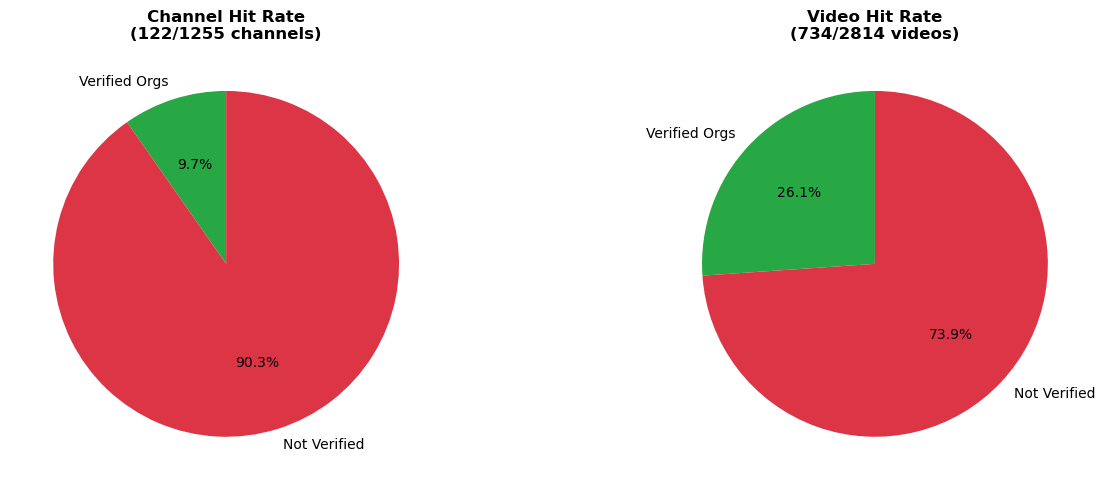

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

channel_data = [len(matched_df), len(unmatched_df)]
channel_labels = ['Verified Orgs', 'Not Verified']
colors = ['#28a745', '#dc3545']

axes[0].pie(channel_data, labels=channel_labels, autopct='%1.1f%%', colors=colors, startangle=90)
axes[0].set_title(f'Channel Hit Rate\n({len(matched_df)}/{len(channels_df)} channels)', fontsize=12, fontweight='bold')

if len(matched_df) > 0:
    video_data = [len(videos_from_verified), len(videos_not_verified)]
    axes[1].pie(video_data, labels=channel_labels, autopct='%1.1f%%', colors=colors, startangle=90)
    axes[1].set_title(f'Video Hit Rate\n({len(videos_from_verified)}/{len(videos_df)} videos)', fontsize=12, fontweight='bold')
else:
    axes[1].text(0.5, 0.5, 'No matched videos', ha='center', va='center')
    axes[1].set_title('Video Hit Rate', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## 6. Matched Channels Details

In [9]:
if len(matched_df) > 0:
    print("Verified Organizations with YouTube Channels Found:")
    matched_df_sorted = matched_df.sort_values('subscriber_count', ascending=False)
    display(matched_df_sorted[['verified_org', 'verified_handle', 'channel_handle', 'subscriber_count', 'video_count']])
else:
    print("No matched channels found.")

Verified Organizations with YouTube Channels Found:


,verified_org,verified_handle,channel_handle,subscriber_count,video_count
9,Mayo Clinic Hospital Arizona,@MayoClinic,@mayoclinic,1220000,11882
12,The Cleveland Clinic Foundation,@clevelandclinic,@clevelandclinic,697000,6101
18,UCLA Medical Center,@UCLAHealth,@uclahealth,569000,3032
14,Johns Hopkins Hospital,@JohnsHopkinsMedicine,@johnshopkinsmedicine,477000,4732
113,VA,@DeptVetAffairs,@deptvetaffairs,443000,2444
...,...,...,...,...,...
102,Crozer-Chester Medical Center (PACC),@CrozerHealth,@crozerhealth,1110,109
42,The European Society for Organ Transplantation,@ESOTtransplant,@esottransplant,1100,430
61,BC Transplant,@BC_Transplant,@bc_transplant,952,151
104,UNOS,@unosnews,@unosnews,939,79


In [13]:
if len(videos_from_verified) > 0:
    print("Videos from Verified Organizations:")
    
    verified_videos_with_info = videos_from_verified.merge(
        matched_df[['channel_id', 'verified_org', 'verified_handle']],
        on='channel_id',
        how='left'
    )
    
    verified_videos_display = verified_videos_with_info[[
        'video_id', 'title', 'verified_org', 'verified_handle', 
        'published_at', 'view_count', 'like_count'
    ]].copy()
    
    verified_videos_display = verified_videos_display.sort_values('view_count', ascending=False)
    print(f"\nTotal verified videos: {len(verified_videos_display)}")
    print(f"\nTop 30 by views:")
    display(verified_videos_display.head(30))
else:
    print("No verified videos found.")

Videos from Verified Organizations:

Total verified videos: 734

Top 30 by views:


,video_id,title,verified_org,verified_handle,published_at,view_count,like_count
169,HYWmYJNg5Jw,Heart in a Box: UCLA patient's life-saving donor heart arrives 'warm and bea...,UCLA Medical Center,@UCLAHealth,2011-08-04T00:13:23Z,18769061,121597
104,S3CegUhEd7Y,6 Warning Signs of Pancreatic Cancer,The Cleveland Clinic Foundation,@clevelandclinic,2022-01-21T05:00:22Z,7023879,16988
378,I12PMiX5h3E,Animation - Coronary stent placement,Mayo Clinic Hospital Arizona,@MayoClinic,2019-10-02T19:48:11Z,5092401,7279
261,Kriob0nAuyU,Experience a Heart Transplant in 360°,UT Southwestern Medical Center/ (TXSP),@UTSWMed,2018-03-13T15:53:01Z,2851845,26567
476,biGuwQhuAsk,Heart Transplant Recipient Meets Donor Family For The First Time,Westchester Medical Center (NYWC),@WMCHealth,2018-09-13T16:01:21Z,2649583,31670
111,4Zxvm3MSb8k,The Whipple Procedure | Johns Hopkins Medicine,Johns Hopkins Hospital,@JohnsHopkinsMedicine,2013-01-03T15:28:02Z,1618486,11564
289,I6ypRSWyeXc,Single-Port Robotic-Assisted Extraperitoneal Kidney Transplantation (Graphic),The Cleveland Clinic Foundation,@clevelandclinic,2022-02-02T17:31:17Z,1606118,3049
389,A0Q0XmmoMlo,Lung Transplant Surgery,Medical University of South Carolina,@medunivsc,2014-09-12T16:18:59Z,1408963,8303
305,Jxb8RVrgjQo,Medical Animation: Living Donor Liver Transplant | Cincinnati Children's,Cincinnati Children's Hospital,@CincinnatiChildrens,2021-05-05T20:04:52Z,1390931,0
125,pke1WhLNoHc,Kidney Transplant Surgery. Living-Donor Kidney Transplant - 2019,UT Southwestern Medical Center/ (TXSP),@UTSWMed,2019-05-03T16:28:10Z,1338471,14151


In [ ]:
if len(videos_from_verified) > 0:
    verified_videos_with_channel = videos_from_verified.merge(
        matched_df[['channel_id', 'verified_org', 'verified_handle', 'subscriber_count']],
        on='channel_id',
        how='left'
    )
    
    verified_export = verified_videos_with_channel[[
        'video_id', 'title', 'verified_org', 'verified_handle', 
        'published_at', 'view_count', 'like_count', 'subscriber_count'
    ]].copy()
    
    verified_export.columns = [
        'video_id', 'video_title', 'organization', 'channel_handle',
        'published_at', 'video_views', 'video_likes', 'channel_subscribers'
    ]
    
    verified_export = verified_export.sort_values('video_views', ascending=False)
    
    verified_videos_file = 'output/Verified_Videos_From_Credible_Orgs.csv'
    verified_export.to_csv(verified_videos_file, index=False)
    
    print(f"Exported {len(verified_export)} verified videos to: {verified_videos_file}")
else:
    print("No verified videos to export.")

## 6. unMatched Channels Details

In [11]:
if len(unmatched_df) > 0:
    print("Channels NOT in Verified Organizations:")
    unmatched_df_sorted = unmatched_df.sort_values('subscriber_count', ascending=False)
    display(unmatched_df_sorted[['channel_handle', 'channel_title', 'subscriber_count', 'video_count']].head(50))
else:
    print("All channels matched.")

Channels NOT in Verified Organizations:


,channel_handle,channel_title,subscriber_count,video_count
530,@tedx,TEDx Talks,43700000,245636
442,@zackdfilms,Zack D. Films,24000000,2429
151,@teded,TED-Ed,22000000,2307
103,@abcnews,ABC News,19100000,106039
59,@cnn,CNN,18800000,176557
453,@aljazeeraenglish,Al Jazeera English,16800000,131290
687,@ndtv,NDTV,15300000,244279
75,@drberg,Dr. Eric Berg DC,14000000,5719
345,@insideedition,Inside Edition,13700000,38895
467,@wired,WIRED,12500000,4088


## 7. Export Unmatched Videos for Review

In [12]:
if len(videos_not_verified) > 0:
    unmatched_channel_ids = set(unmatched_df['channel_id'])
    videos_with_channel_info = videos_not_verified.merge(
        channels_df[['channel_id', 'handle', 'title', 'subscriber_count']],
        on='channel_id',
        how='left',
        suffixes=('_video', '_channel')
    )
    
    videos_export = videos_with_channel_info[[
        'video_id', 'title_video', 'handle', 'title_channel', 
        'published_at', 'view_count', 'like_count', 'subscriber_count'
    ]].copy()
    
    videos_export.columns = [
        'video_id', 'video_title', 'channel_handle', 'channel_name',
        'published_at', 'video_views', 'video_likes', 'channel_subscribers'
    ]
    
    videos_export = videos_export.sort_values('channel_subscribers', ascending=False)
    
    unmatched_videos_file = 'output/Unmatched_Videos_For_Review.csv'
    videos_export.to_csv(unmatched_videos_file, index=False)
    
    print(f"Exported {len(videos_export)} unmatched videos to: {unmatched_videos_file}")
else:
    print("All videos are from verified organizations.")

Exported 2080 unmatched videos to: output/Unmatched_Videos_For_Review.csv
